# MindTune Featured Data Analysis

Analysis and visualization of the feature-engineered EEG dataset with rolling statistics, ratios, and encoded labels.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Load Featured Data

In [71]:
df = pd.read_csv('featured_mindtune.csv')
print(f"Dataset shape: {df.shape}")
print(f"Sessions: {df['session_id'].nunique()}")
print(f"Participants: {df['participant_id'].nunique()}")
print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")
df.head()

Dataset shape: (11945, 42)
Sessions: 65
Participants: 54

Columns (42): ['session_id', 'participant_id', 'timestamp_ms', 'label_3class', 'delta_pct', 'theta_pct', 'low_alpha_pct', 'high_alpha_pct', 'low_beta_pct', 'high_beta_pct', 'low_gamma_pct', 'mid_gamma_pct', 'attention', 'meditation', 'signal_quality', 'marker_ev_praised_active', 'marker_ev_qna_active', 'marker_ev_question_active', 'marker_ev_scolded_active', 'marker_ev_speaking_active', 'marker_ev_tech_issue_active', 'session_time_sec', 'theta_beta_ratio', 'alpha_beta_ratio', 'slow_fast_ratio', 'delta_pct_roll_mean_5', 'delta_pct_roll_std_5', 'theta_pct_roll_mean_5', 'theta_pct_roll_std_5', 'low_alpha_pct_roll_mean_5', 'low_alpha_pct_roll_std_5', 'high_alpha_pct_roll_mean_5', 'high_alpha_pct_roll_std_5', 'low_beta_pct_roll_mean_5', 'low_beta_pct_roll_std_5', 'high_beta_pct_roll_mean_5', 'high_beta_pct_roll_std_5', 'attention_roll_mean_5', 'attention_roll_std_5', 'meditation_roll_mean_5', 'meditation_roll_std_5', 'label_encoded']

,session_id,participant_id,timestamp_ms,label_3class,delta_pct,theta_pct,low_alpha_pct,high_alpha_pct,low_beta_pct,high_beta_pct,...,high_alpha_pct_roll_std_5,low_beta_pct_roll_mean_5,low_beta_pct_roll_std_5,high_beta_pct_roll_mean_5,high_beta_pct_roll_std_5,attention_roll_mean_5,attention_roll_std_5,meditation_roll_mean_5,meditation_roll_std_5,label_encoded
0,0054,P0054,1774857972940,neutral,0.932067,0.017215,0.004965,0.017741,0.017175,0.007442,...,0.000000,0.017175,0.000000,0.007442,0.000000,77.0,0.0,97.0,0.0,1
1,0054,P0054,1774857973920,neutral,0.330172,0.166994,0.084490,0.121249,0.132139,0.105784,...,0.073191,0.074657,0.081292,0.056613,0.069538,77.0,0.0,97.0,0.0,1
2,0054,P0054,1774857976914,neutral,0.603905,0.206416,0.071130,0.051604,0.029289,0.023710,...,0.052775,0.059534,0.063169,0.045645,0.052713,77.0,0.0,97.0,0.0,1
3,0054,P0054,1774857977910,neutral,0.925271,0.044120,0.009542,0.001648,0.006471,0.011678,...,0.053049,0.046268,0.058001,0.037153,0.046270,77.0,0.0,97.0,0.0,1
4,0054,P0054,1774857978884,neutral,0.485875,0.055797,0.018615,0.032424,0.319023,0.065956,...,0.046471,0.100819,0.131917,0.042914,0.042090,77.0,0.0,97.0,0.0,1


In [59]:
df.drop_duplicates(subset=['session_id', 'timestamp_ms'], keep='first')

In [60]:
# Data summary
print("\nData Info:")
df.info()
print("\n" + "="*50)
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Data Info:
<class 'pandas.DataFrame'>
Index: 8940 entries, 0 to 10963
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   session_id                   8940 non-null   str    
 1   participant_id               8940 non-null   str    
 2   timestamp_ms                 8940 non-null   int64  
 3   label_3class                 8940 non-null   str    
 4   delta_pct                    8940 non-null   float64
 5   theta_pct                    8940 non-null   float64
 6   low_alpha_pct                8940 non-null   float64
 7   high_alpha_pct               8940 non-null   float64
 8   low_beta_pct                 8940 non-null   float64
 9   high_beta_pct                8940 non-null   float64
 10  low_gamma_pct                8940 non-null   float64
 11  mid_gamma_pct                8940 non-null   float64
 12  attention                    8940 non-null   int64  
 13  meditation           

## 2. Label Distribution

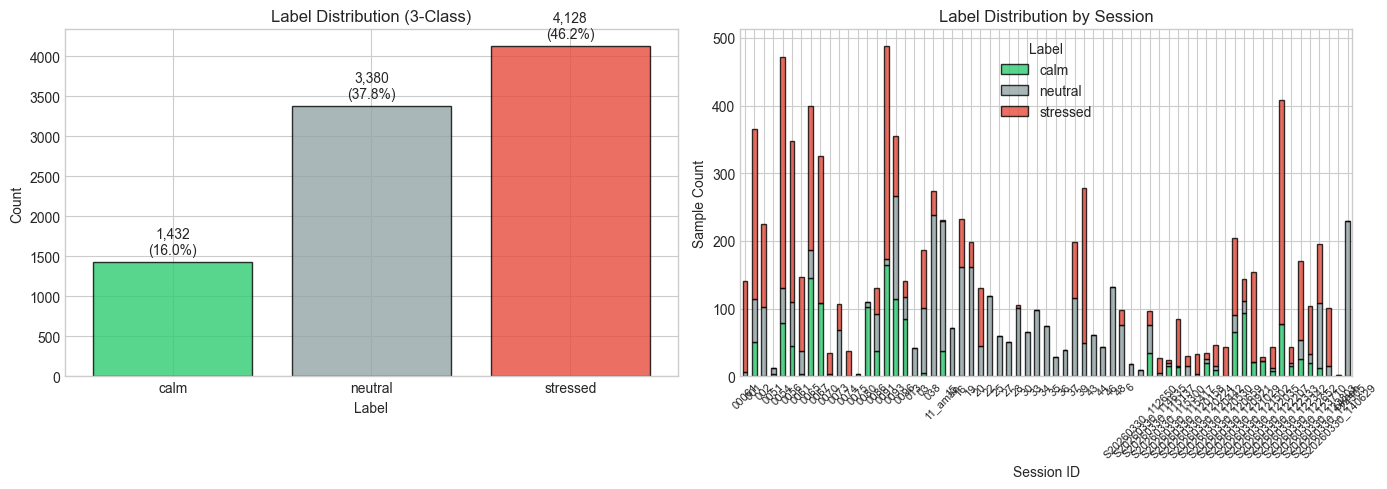


Label Distribution:
label_3class
calm        1432
neutral     3380
stressed    4128
Name: count, dtype: int64

Label proportions:
label_3class
calm        16.02
neutral     37.81
stressed    46.17
Name: count, dtype: float64%


In [61]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3-class labels
label_counts = df['label_3class'].value_counts().sort_index()
colors = ['#2ecc71', '#95a5a6', '#e74c3c']  # green, gray, red
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution (3-Class)')
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(label_counts.index)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Labels by session
session_labels = df.groupby(['session_id', 'label_3class']).size().unstack(fill_value=0)
session_labels.plot(kind='bar', stacked=True, ax=axes[1], color=colors, edgecolor='black', alpha=0.8, legend=True)
axes[1].set_xlabel('Session ID')
axes[1].set_ylabel('Sample Count')
axes[1].set_title('Label Distribution by Session')
axes[1].legend(title='Label', labels=['calm', 'neutral', 'stressed'])
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

print("\nLabel Distribution:")
print(label_counts)
print(f"\nLabel proportions:\n{(label_counts / len(df) * 100).round(2)}%")

## 3. Signal Quality Analysis

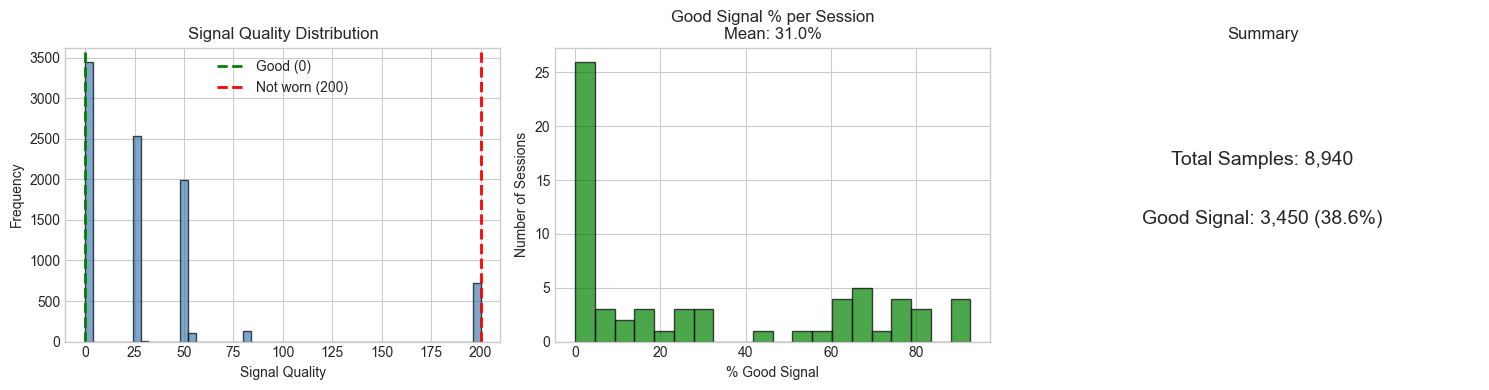

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Signal quality distribution
axes[0].hist(df['signal_quality'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='green', linestyle='--', label='Good (0)', linewidth=2)
axes[0].axvline(x=200, color='red', linestyle='--', label='Not worn (200)', linewidth=2)
axes[0].set_xlabel('Signal Quality')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Signal Quality Distribution')
axes[0].legend()

# Good signal % by session
good_pct = df.groupby('session_id').apply(lambda x: (x['signal_quality'] == 0).mean() * 100)
axes[1].hist(good_pct, bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('% Good Signal')
axes[1].set_ylabel('Number of Sessions')
axes[1].set_title(f'Good Signal % per Session\nMean: {good_pct.mean():.1f}%')

# Summary stats
good_total = (df['signal_quality'] == 0).sum()
good_pct_total = (df['signal_quality'] == 0).mean() * 100
axes[2].text(0.5, 0.6, f'Total Samples: {len(df):,}', ha='center', fontsize=14, transform=axes[2].transAxes)
axes[2].text(0.5, 0.4, f'Good Signal: {good_total:,} ({good_pct_total:.1f}%)', ha='center', fontsize=14, transform=axes[2].transAxes)
axes[2].axis('off')
axes[2].set_title('Summary')

plt.tight_layout()
plt.show()

## 4. Brainwave Band Percentages by Label

Labels found in data: ['calm', 'neutral', 'stressed']
Band data shape: (3, 8)
Plotting labels: ['calm', 'neutral', 'stressed']


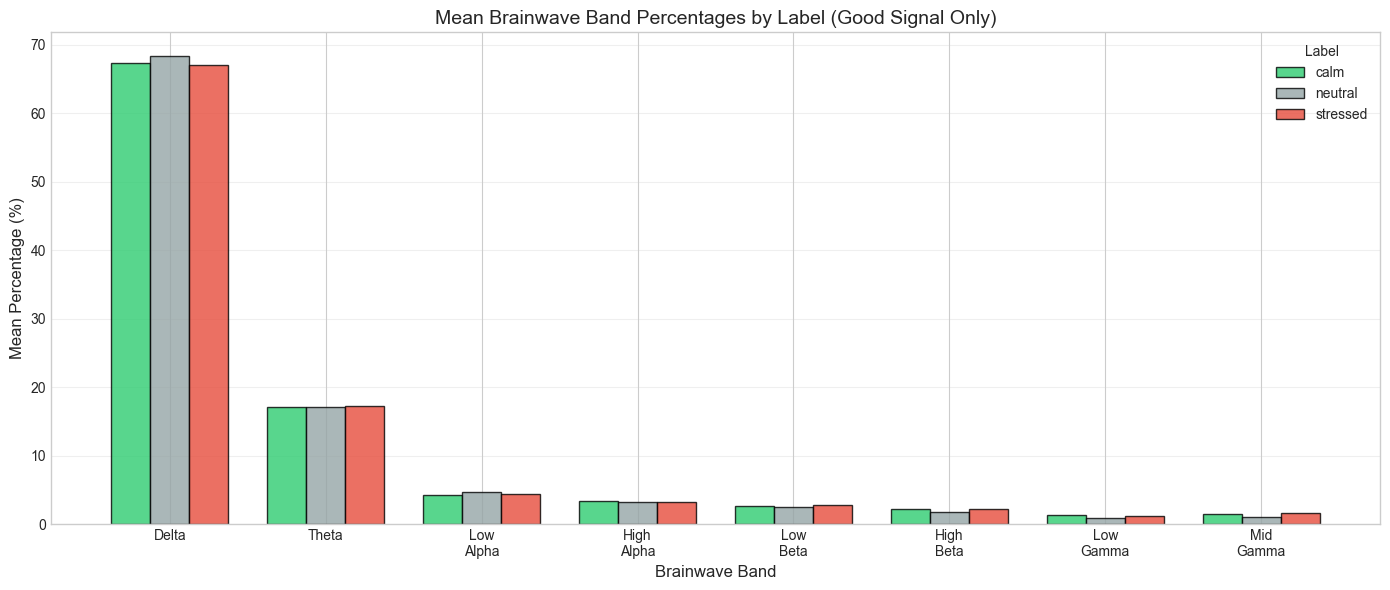


Mean Band Percentages by Label:
              delta_pct  theta_pct  low_alpha_pct  high_alpha_pct  \
label_3class                                                        
calm              67.43      17.21           4.29            3.37   
neutral           68.41      17.08           4.74            3.30   
stressed          67.11      17.30           4.49            3.29   

              low_beta_pct  high_beta_pct  low_gamma_pct  mid_gamma_pct  
label_3class                                                             
calm                  2.70           2.18           1.32           1.50  
neutral               2.50           1.84           0.99           1.14  
stressed              2.79           2.18           1.21           1.62  


In [63]:
# Define band columns and label mapping
band_pct_cols = ['delta_pct', 'theta_pct', 'low_alpha_pct', 'high_alpha_pct', 
                 'low_beta_pct', 'high_beta_pct', 'low_gamma_pct', 'mid_gamma_pct']
labels_map = {'calm': 'calm', 'neutral': 'neutral', 'stressed': 'stressed'}
colors_map = {'calm': '#2ecc71', 'neutral': '#95a5a6', 'stressed': '#e74c3c'}

# Filter good signal and calculate mean by label
df_good = df[df['signal_quality'] == 0].copy()
band_by_label = df_good.groupby('label_3class')[band_pct_cols].mean()

print(f"Labels found in data: {sorted(df_good['label_3class'].unique())}")
print(f"Band data shape: {band_by_label.shape}")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(band_pct_cols))
width = 0.25

# Get unique labels and sort them
unique_labels = sorted(band_by_label.index)
print(f"Plotting labels: {unique_labels}")

for i, label in enumerate(unique_labels):
    values = band_by_label.loc[label].values * 100
    color = colors_map.get(label, '#999999')
    ax.bar(x + i*width, values, width, label=label, color=color, edgecolor='black', alpha=0.8)

ax.set_xlabel('Brainwave Band', fontsize=12)
ax.set_ylabel('Mean Percentage (%)', fontsize=12)
ax.set_title('Mean Brainwave Band Percentages by Label (Good Signal Only)', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels([b.replace('_pct', '').replace('_', '\n').title() for b in band_pct_cols], rotation=0, ha='center')
ax.legend(title='Label', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMean Band Percentages by Label:")
print((band_by_label * 100).round(2))

## 5. Attention & Meditation by Label

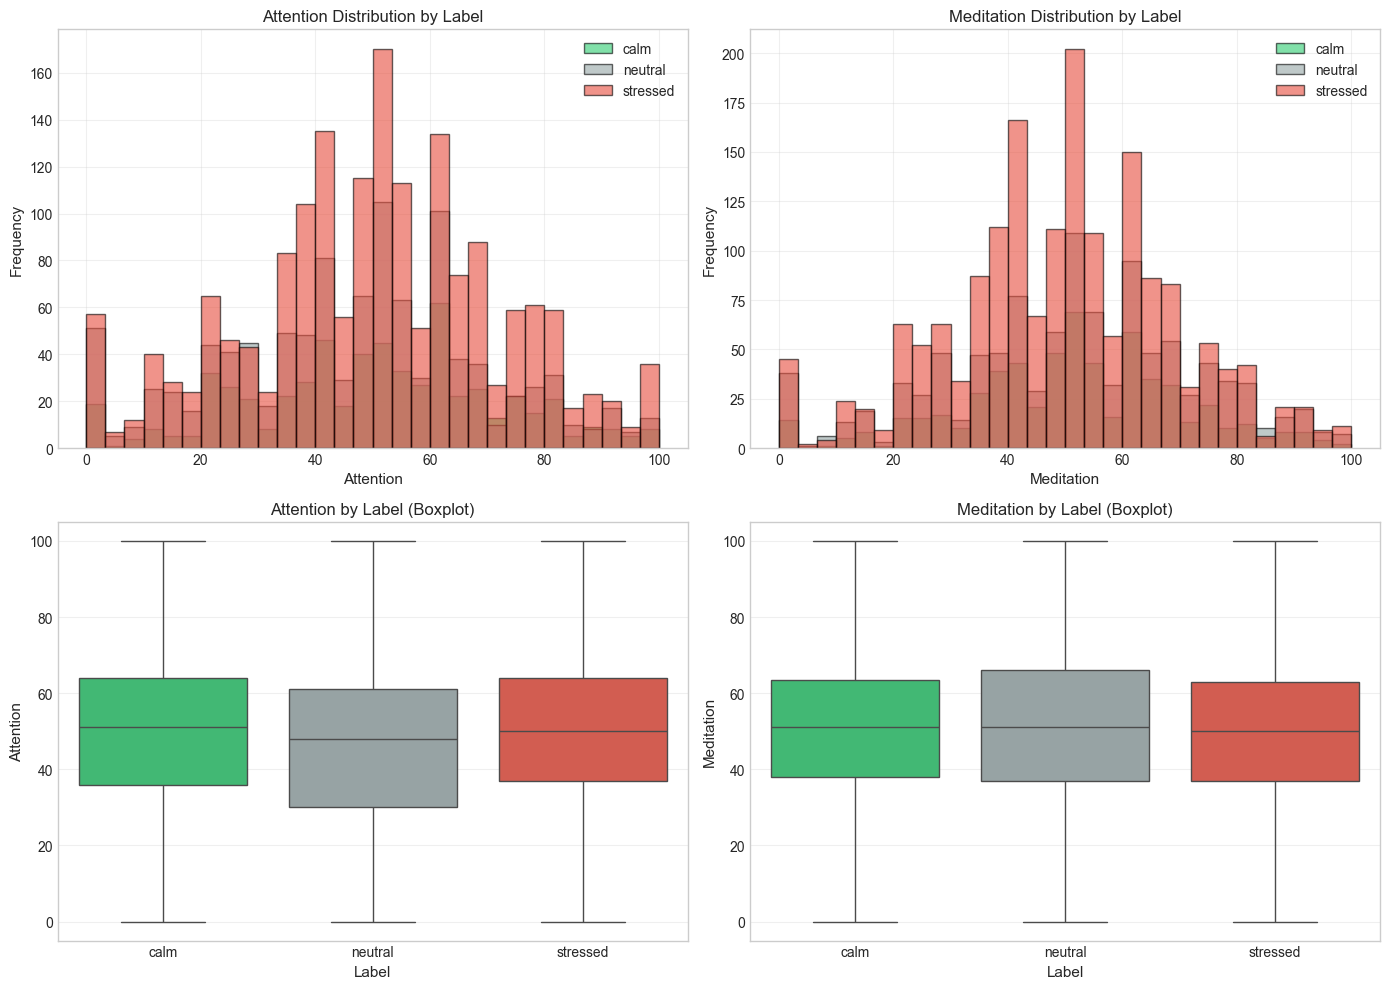


Attention & Meditation Statistics by Label:
             attention                 meditation                
                  mean    std min  max       mean    std min  max
label_3class                                                     
calm             49.85  21.78   0  100      50.89  18.88   0  100
neutral          46.47  22.54   0  100      50.75  21.48   0  100
stressed         49.75  22.11   0  100      49.11  19.49   0  100


In [64]:
# Use the already filtered df_good from previous cell
if 'df_good' not in locals():
    df_good = df[df['signal_quality'] == 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color mapping for labels
label_colors = {'calm': '#2ecc71', 'neutral': '#95a5a6', 'stressed': '#e74c3c'}

# Attention by label
for label in sorted(df_good['label_3class'].unique()):
    data = df_good[df_good['label_3class'] == label]['attention']
    axes[0, 0].hist(data, bins=30, alpha=0.6, label=label, 
                    color=label_colors.get(label, '#999999'), edgecolor='black')
axes[0, 0].set_xlabel('Attention', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Attention Distribution by Label', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Meditation by label
for label in sorted(df_good['label_3class'].unique()):
    data = df_good[df_good['label_3class'] == label]['meditation']
    axes[0, 1].hist(data, bins=30, alpha=0.6, label=label, 
                    color=label_colors.get(label, '#999999'), edgecolor='black')
axes[0, 1].set_xlabel('Meditation', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Meditation Distribution by Label', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Boxplot - Attention (using seaborn for better control)
sns.boxplot(data=df_good, x='label_3class', y='attention', ax=axes[1, 0],
            order=sorted(df_good['label_3class'].unique()),
            palette=label_colors)
axes[1, 0].set_xlabel('Label', fontsize=11)
axes[1, 0].set_ylabel('Attention', fontsize=11)
axes[1, 0].set_title('Attention by Label (Boxplot)', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

# Boxplot - Meditation (using seaborn for better control)
sns.boxplot(data=df_good, x='label_3class', y='meditation', ax=axes[1, 1],
            order=sorted(df_good['label_3class'].unique()),
            palette=label_colors)
axes[1, 1].set_xlabel('Label', fontsize=11)
axes[1, 1].set_ylabel('Meditation', fontsize=11)
axes[1, 1].set_title('Meditation by Label (Boxplot)', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAttention & Meditation Statistics by Label:")
stats_summary = df_good.groupby('label_3class')[['attention', 'meditation']].agg(['mean', 'std', 'min', 'max'])
print(stats_summary.round(2))

## 6. Engineered Features: Ratios

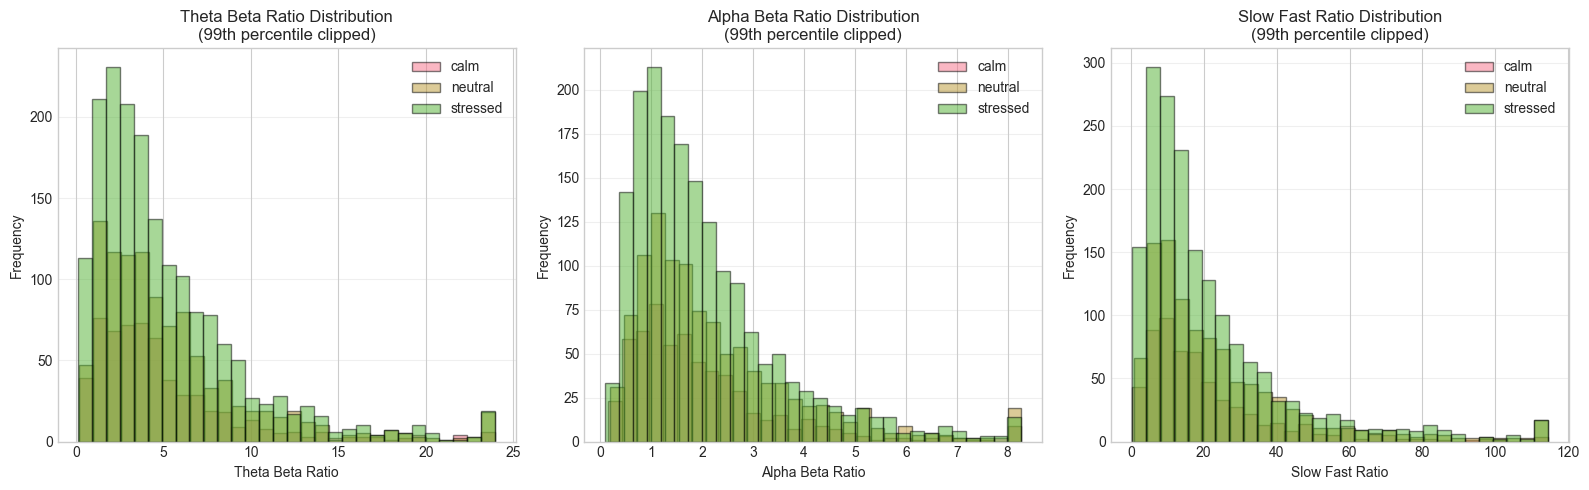


Ratio Statistics by Label:
             theta_beta_ratio                                             \
                        count  mean   std   min   25%   50%   75%    max   
label_3class                                                               
calm                    603.0  5.05  4.50  0.17  2.16  3.84  6.33  30.95   
neutral                1067.0  5.60  5.16  0.19  2.32  4.18  6.82  54.61   
stressed               1780.0  5.20  4.66  0.14  2.15  3.79  6.85  42.83   

             alpha_beta_ratio        ...              slow_fast_ratio         \
                        count  mean  ...   75%    max           count   mean   
label_3class                         ...                                       
calm                    603.0  2.06  ...  2.50  13.57           603.0  21.44   
neutral                1067.0  2.30  ...  2.94  15.25          1067.0  25.46   
stressed               1780.0  2.06  ...  2.62  14.59          1780.0  21.76   

                                  

In [65]:
ratio_cols = ['theta_beta_ratio', 'alpha_beta_ratio', 'slow_fast_ratio']

# Filter outliers for visualization (99th percentile)
df_ratios = df_good.copy()
for col in ratio_cols:
    p99 = df_ratios[col].quantile(0.99)
    df_ratios.loc[df_ratios[col] > p99, col] = p99

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, ratio in enumerate(ratio_cols):
    for label in sorted(df_ratios['label_3class'].unique()):
        data = df_ratios[df_ratios['label_3class'] == label][ratio]
        axes[i].hist(data, bins=30, alpha=0.5, label=labels_map.get(label, str(label)), edgecolor='black')
    
    axes[i].set_xlabel(ratio.replace('_', ' ').title())
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{ratio.replace("_", " ").title()} Distribution\n(99th percentile clipped)')
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRatio Statistics by Label:")
print(df_good.groupby('label_3class')[ratio_cols].describe().round(2))

## 7. Rolling Mean Features Visualization

In [66]:
# Check if duplicates have identical RAW data across all sessions
print("\nDuplicate Data Quality Check:")
print("="*80)
# Define raw data columns (before feature engineering)
raw_cols = ['timestamp_ms', 'session_time_sec', 'attention', 'meditation', 
            'delta_pct', 'theta_pct', 'low_alpha_pct', 'high_alpha_pct',
            'low_beta_pct', 'high_beta_pct', 'low_gamma_pct', 'mid_gamma_pct',
            'signal_quality', 'label_3class']
# Track results
sessions_with_dupes = []
identical_raw_count = 0
different_raw_count = 0
for session_id in sorted(df['session_id'].unique()):
    df_sess = df[df['session_id'] == session_id]
    
    # Skip sessions with no duplicates
    if df_sess['timestamp_ms'].nunique() == len(df_sess):
        continue
    
    # Get duplicate timestamp groups
    dupes = df_sess[df_sess['timestamp_ms'].duplicated(keep=False)].sort_values('timestamp_ms')
    
    if len(dupes) == 0:
        continue
    
    sessions_with_dupes.append(session_id)
    
    # Check each duplicate group
    session_identical = 0
    session_different = 0
    
    for ts in dupes['timestamp_ms'].unique():
        group = df_sess[df_sess['timestamp_ms'] == ts]
        
        # Check if RAW data is identical
        raw_data_identical = group[raw_cols].drop_duplicates().shape[0] == 1
        
        if raw_data_identical:
            session_identical += 1
        else:
            session_different += 1
            # Print example of non-identical duplicates
            if different_raw_count < 3:  # Show first 3 examples
                print(f"\n⚠️  Session {session_id}, timestamp {ts}: RAW DATA DIFFERS!")
                print(group[raw_cols].to_string())
    
    identical_raw_count += session_identical
    different_raw_count += session_different
    
    print(f"Session {session_id}: {session_identical} identical raw, {session_different} different raw")
print("\n" + "="*80)
print(f"SUMMARY:")
print(f"  Sessions with duplicates: {len(sessions_with_dupes)}")
print(f"  Duplicate groups with IDENTICAL raw data: {identical_raw_count}")
print(f"  Duplicate groups with DIFFERENT raw data: {different_raw_count}")
print(f"\nConclusion:")
if different_raw_count == 0:
    print("  ✅ ALL duplicates have identical raw data → Data pipeline bug")
    print("  ✅ Safe to deduplicate by (session_id, timestamp_ms)")
else:
    print(f"  ❌ {different_raw_count} duplicate groups have DIFFERENT raw data")
    print("  ❌ Deeper investigation needed - possible timestamp precision issue")


Duplicate Data Quality Check:

SUMMARY:
  Sessions with duplicates: 0
  Duplicate groups with IDENTICAL raw data: 0
  Duplicate groups with DIFFERENT raw data: 0

Conclusion:
  ✅ ALL duplicates have identical raw data → Data pipeline bug
  ✅ Safe to deduplicate by (session_id, timestamp_ms)


In [67]:
# Check duplicates across ALL sessions
print("\nDuplicate Analysis Across All Sessions:")
print("="*60)
for session_id in sorted(df['session_id'].unique()):
    df_sess = df[df['session_id'] == session_id]
    total = len(df_sess)
    unique_ts = df_sess['timestamp_ms'].nunique()
    dupes = total - unique_ts
    dupe_pct = (dupes / total) * 100
    
    print(f"Session {session_id}: {total:4d} rows, {dupes:4d} dupes ({dupe_pct:5.1f}%)")
# Overall statistics
print("\n" + "="*60)
total_rows = len(df)
unique_rows = df.drop_duplicates(subset=['session_id', 'timestamp_ms']).shape[0]
total_dupes = total_rows - unique_rows
print(f"TOTAL: {total_rows:,} rows, {total_dupes:,} duplicates ({total_dupes/total_rows*100:.1f}%)")


Duplicate Analysis Across All Sessions:
Session 00061:  141 rows,    0 dupes (  0.0%)
Session 001:  366 rows,    0 dupes (  0.0%)
Session 002:  225 rows,    0 dupes (  0.0%)
Session 0051:   12 rows,    0 dupes (  0.0%)
Session 0054:  472 rows,    0 dupes (  0.0%)
Session 0056:  348 rows,    0 dupes (  0.0%)
Session 0061:  147 rows,    0 dupes (  0.0%)
Session 0065:  400 rows,    0 dupes (  0.0%)
Session 0067:  326 rows,    0 dupes (  0.0%)
Session 0070:   35 rows,    0 dupes (  0.0%)
Session 0073:  107 rows,    0 dupes (  0.0%)
Session 0074:   37 rows,    0 dupes (  0.0%)
Session 0075:    3 rows,    0 dupes (  0.0%)
Session 0080:  110 rows,    0 dupes (  0.0%)
Session 0086:  131 rows,    0 dupes (  0.0%)
Session 0091:  488 rows,    0 dupes (  0.0%)
Session 0093:  355 rows,    0 dupes (  0.0%)
Session 0096:  141 rows,    0 dupes (  0.0%)
Session 013:   42 rows,    0 dupes (  0.0%)
Session 03:  187 rows,    0 dupes (  0.0%)
Session 038:  274 rows,    0 dupes (  0.0%)
Session 11_aman:  2

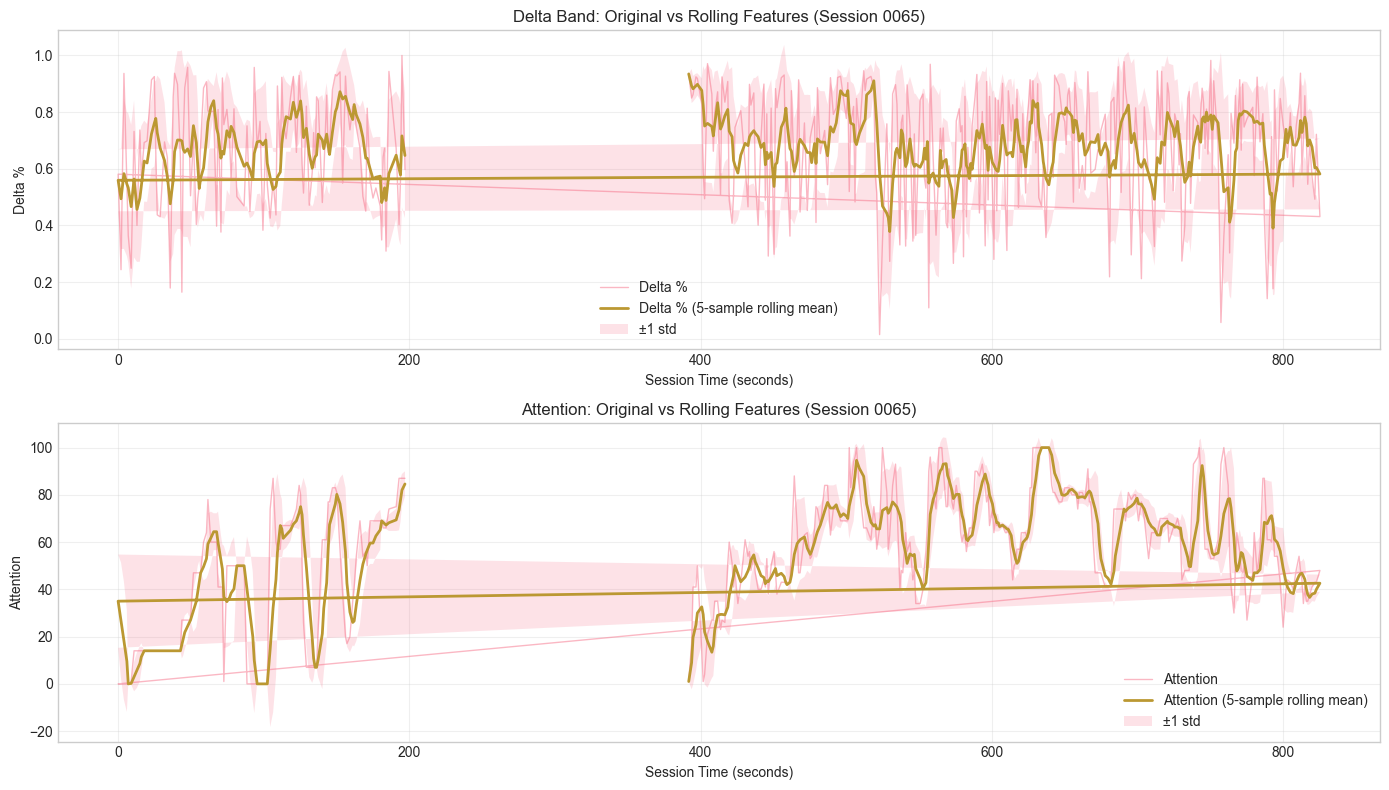

In [68]:
# Select a sample session to visualize rolling features
sample_session = df['session_id'].iloc[105]
df_session = df[df['session_id'] == sample_session].copy()

# Plot original vs rolling mean for delta and theta
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Delta
axes[0].plot(df_session['session_time_sec'], df_session['delta_pct'], label='Delta %', alpha=0.5, linewidth=1)
axes[0].plot(df_session['session_time_sec'], df_session['delta_pct_roll_mean_5'], label='Delta % (5-sample rolling mean)', linewidth=2)
axes[0].fill_between(df_session['session_time_sec'], 
                     df_session['delta_pct_roll_mean_5'] - df_session['delta_pct_roll_std_5'],
                     df_session['delta_pct_roll_mean_5'] + df_session['delta_pct_roll_std_5'],
                     alpha=0.2, label='±1 std')
axes[0].set_xlabel('Session Time (seconds)')
axes[0].set_ylabel('Delta %')
axes[0].set_title(f'Delta Band: Original vs Rolling Features (Session {sample_session})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Attention
axes[1].plot(df_session['session_time_sec'], df_session['attention'], label='Attention', alpha=0.5, linewidth=1)
axes[1].plot(df_session['session_time_sec'], df_session['attention_roll_mean_5'], label='Attention (5-sample rolling mean)', linewidth=2)
axes[1].fill_between(df_session['session_time_sec'], 
                     df_session['attention_roll_mean_5'] - df_session['attention_roll_std_5'],
                     df_session['attention_roll_mean_5'] + df_session['attention_roll_std_5'],
                     alpha=0.2, label='±1 std')
axes[1].set_xlabel('Session Time (seconds)')
axes[1].set_ylabel('Attention')
axes[1].set_title(f'Attention: Original vs Rolling Features (Session {sample_session})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Correlation Heatmap

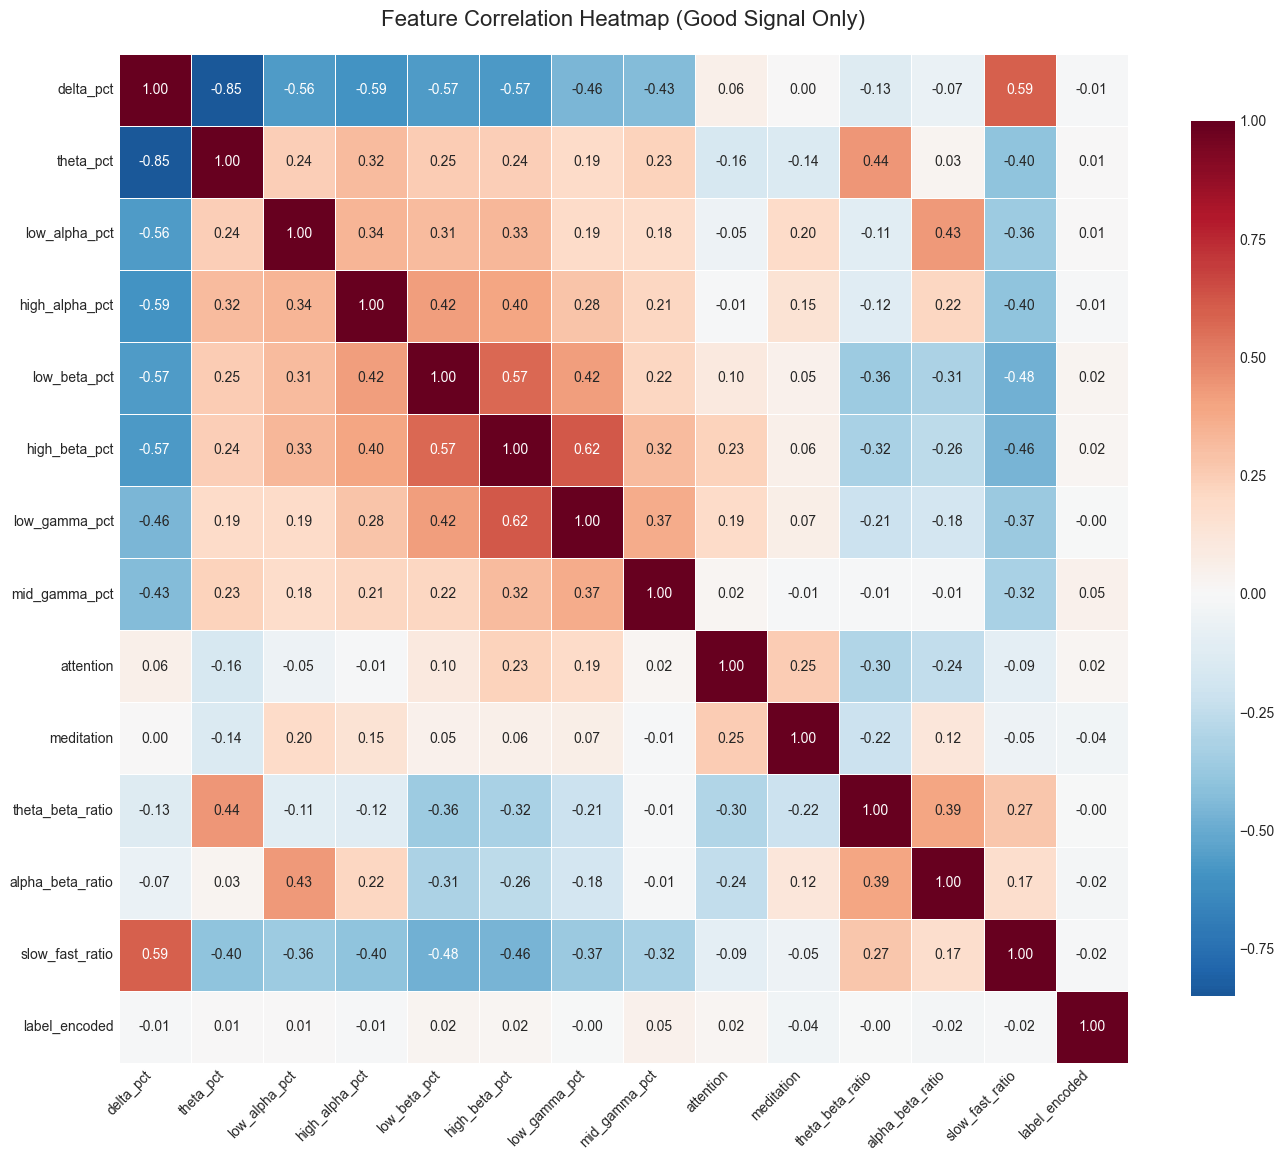


Top 10 Correlations with Label:
mid_gamma_pct       0.047240
meditation          0.038814
low_beta_pct        0.024646
high_beta_pct       0.022254
alpha_beta_ratio    0.020287
attention           0.019057
slow_fast_ratio     0.017740
delta_pct           0.014524
high_alpha_pct      0.007925
low_alpha_pct       0.006333
Name: label_encoded, dtype: float64


In [69]:
# Select key features for correlation
key_features = band_pct_cols + ['attention', 'meditation'] + ratio_cols + ['label_encoded']
corr_data = df_good[key_features].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Good Signal Only)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nTop 10 Correlations with Label:")
label_corr = corr_data['label_encoded'].abs().sort_values(ascending=False)
print(label_corr[1:11])  # Skip self-correlation

## 9. Event Markers Analysis

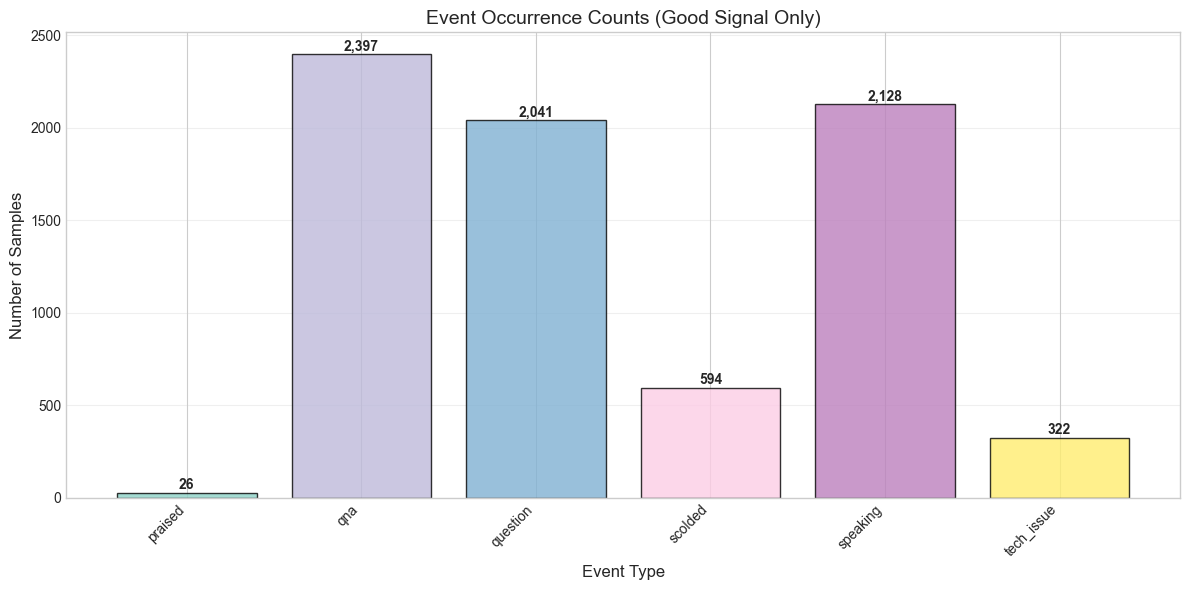


Event Distribution:
qna           2397
speaking      2128
question      2041
scolded        594
tech_issue     322
praised         26
dtype: int64

Event percentages:
qna           48.06
speaking      42.66
question      40.92
scolded       11.91
tech_issue     6.46
praised        0.52
dtype: float64


In [40]:
event_cols = ['marker_ev_praised_active', 'marker_ev_qna_active', 'marker_ev_question_active',
              'marker_ev_scolded_active', 'marker_ev_speaking_active', 'marker_ev_tech_issue_active']

event_counts = df_good[event_cols].sum()
event_counts.index = [e.replace('marker_ev_', '').replace('_active', '') for e in event_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(event_counts)))
bars = ax.bar(event_counts.index, event_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_xlabel('Event Type', fontsize=12)
ax.set_title('Event Occurrence Counts (Good Signal Only)', fontsize=14)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, event_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            f'{int(val):,}', ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nEvent Distribution:")
print(event_counts.sort_values(ascending=False))
print(f"\nEvent percentages:")
print((event_counts / len(df_good) * 100).sort_values(ascending=False).round(2))

## 10. Attention & Meditation During Events

In [ ]:
# Compare attention and meditation during events (ON vs OFF)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, metric in enumerate(['attention', 'meditation']):
    event_means = []
    event_names = []
    
    for event_col in event_cols:
        if df_good[event_col].sum() > 10:
            on_mean = df_good[df_good[event_col] == 1][metric].mean()
            off_mean = df_good[df_good[event_col] == 0][metric].mean()
            event_means.append([off_mean, on_mean])
            event_name = event_col.replace('marker_ev_', '').replace('_active', '')
            event_names.append(event_name)
    
    x = np.arange(len(event_names))
    width = 0.35
    
    axes[idx].bar(x - width/2, [m[0] for m in event_means], width, label='Event OFF', 
                  alpha=0.8, color='steelblue', edgecolor='black')
    axes[idx].bar(x + width/2, [m[1] for m in event_means], width, label='Event ON', 
                  alpha=0.8, color='coral', edgecolor='black')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(event_names, rotation=45, ha='right')
    axes[idx].set_ylabel(f'Mean {metric.title()}', fontsize=11)
    axes[idx].set_title(f'{metric.title()} During Events (ON vs OFF)', fontsize=12)
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAttention & Meditation change summary:")
for i, name in enumerate(event_names):
    att_change = ((event_means[0][1] - event_means[0][0]) / event_means[0][0]) * 100
    med_change = ((event_means[1][1] - event_means[1][0]) / event_means[1][0]) * 100
    print(f"{name}: Attention {att_change:+.1f}%, Meditation {med_change:+.1f}%")

## 11. Temporal Analysis: Session Time

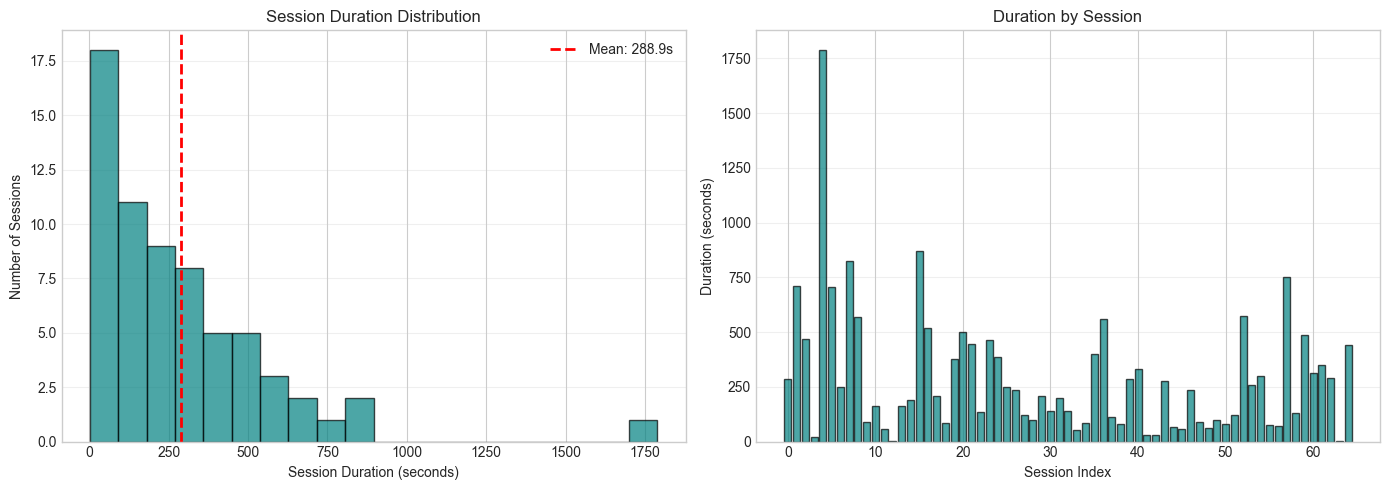


Session Duration Statistics:
Mean: 288.92s
Median: 208.57s
Min: 1.98s
Max: 1788.62s
Std: 286.52s


In [41]:
# Session duration
session_durations = df.groupby('session_id')['session_time_sec'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram
axes[0].hist(session_durations, bins=20, edgecolor='black', alpha=0.7, color='teal')
axes[0].axvline(session_durations.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {session_durations.mean():.1f}s')
axes[0].set_xlabel('Session Duration (seconds)')
axes[0].set_ylabel('Number of Sessions')
axes[0].set_title('Session Duration Distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Session duration bar chart
axes[1].bar(range(len(session_durations)), session_durations.values, color='teal', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Session Index')
axes[1].set_ylabel('Duration (seconds)')
axes[1].set_title('Duration by Session')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSession Duration Statistics:")
print(f"Mean: {session_durations.mean():.2f}s")
print(f"Median: {session_durations.median():.2f}s")
print(f"Min: {session_durations.min():.2f}s")
print(f"Max: {session_durations.max():.2f}s")
print(f"Std: {session_durations.std():.2f}s")

## 12. Summary Statistics by Label

In [42]:
# Comprehensive summary
summary_features = band_pct_cols + ['attention', 'meditation'] + ratio_cols
summary = df_good.groupby('label_3class')[summary_features].mean()
summary.index = [labels_map.get(i, str(i)) for i in summary.index]

print("\n" + "="*80)
print("MEAN FEATURE VALUES BY LABEL (Good Signal Only)")
print("="*80)
print(summary.T.round(4))

# Calculate differences
if 'stressed' in summary.index and 'calm' in summary.index:
    diff = summary.loc['stressed'] - summary.loc['calm']
    pct_change = ((summary.loc['stressed'] - summary.loc['calm']) / (summary.loc['calm'] + 1e-10)) * 100
    
    print("\n" + "="*80)
    print("STRESSED vs CALM: Differences and % Change")
    print("="*80)
    comparison = pd.DataFrame({
        'Difference': diff,
        '% Change': pct_change
    })
    print(comparison.round(2))


MEAN FEATURE VALUES BY LABEL (Good Signal Only)
                     calm  neutral  stressed
delta_pct          0.6711   0.6793    0.6698
theta_pct          0.1728   0.1725    0.1734
low_alpha_pct      0.0449   0.0481    0.0451
high_alpha_pct     0.0342   0.0337    0.0331
low_beta_pct       0.0272   0.0250    0.0276
high_beta_pct      0.0217   0.0192    0.0221
low_gamma_pct      0.0132   0.0103    0.0123
mid_gamma_pct      0.0149   0.0118    0.0167
attention         50.5082  47.5814   50.3158
meditation        52.3636  50.9352   49.1367
theta_beta_ratio   4.9461   5.5835    5.1392
alpha_beta_ratio   2.0928   2.2984    2.0578
slow_fast_ratio   20.4728  24.9479   21.6588

STRESSED vs CALM: Differences and % Change
                  Difference  % Change
delta_pct              -0.00     -0.19
theta_pct               0.00      0.33
low_alpha_pct           0.00      0.49
high_alpha_pct         -0.00     -3.45
low_beta_pct            0.00      1.34
high_beta_pct           0.00      1.87
low_

## 13. Key Insights

In [43]:
print("\n" + "="*80)
print("KEY INSIGHTS FROM FEATURED DATA")
print("="*80)

print(f"\n1. DATASET OVERVIEW")
print(f"   - Total samples: {len(df):,}")
print(f"   - Sessions: {df['session_id'].nunique()}")
print(f"   - Participants: {df['participant_id'].nunique()}")
print(f"   - Good signal quality: {(df['signal_quality'] == 0).sum():,} ({(df['signal_quality'] == 0).mean()*100:.1f}%)")

print(f"\n2. LABEL DISTRIBUTION")
for label, count in label_counts.items():
    print(f"   - {labels_map.get(label, str(label)).capitalize()}: {count:,} ({count/len(df)*100:.1f}%)")

print(f"\n3. FEATURE ENGINEERING")
print(f"   - Brainwave percentages: Normalized band power to 0-1 scale")
print(f"   - Ratios: theta/beta, alpha/beta, slow/fast wave ratios")
print(f"   - Rolling statistics: 5-sample window means and standard deviations")
print(f"   - Temporal: session_time_sec for time-series analysis")

print(f"\n4. TOP FEATURES CORRELATED WITH LABEL")
for i, (feat, corr) in enumerate(label_corr[1:6].items(), 1):
    print(f"   {i}. {feat}: {corr:.3f}")

print(f"\n5. READY FOR MODELING")
print(f"   - Clean, engineered features ready for ML models")
print(f"   - Encoded labels: 0=calm, 1=neutral, 2=stressed")
print(f"   - Multiple feature types: statistical, temporal, event-based")
print(f"   - Balanced consideration for class imbalance in modeling")

print("\n" + "="*80)


KEY INSIGHTS FROM FEATURED DATA

1. DATASET OVERVIEW
   - Total samples: 11,945
   - Sessions: 65
   - Participants: 54
   - Good signal quality: 4,988 (41.8%)

2. LABEL DISTRIBUTION
   - Calm: 2,097 (17.6%)
   - Neutral: 3,662 (30.7%)
   - Stressed: 6,186 (51.8%)

3. FEATURE ENGINEERING
   - Brainwave percentages: Normalized band power to 0-1 scale
   - Ratios: theta/beta, alpha/beta, slow/fast wave ratios
   - Rolling statistics: 5-sample window means and standard deviations
   - Temporal: session_time_sec for time-series analysis

4. TOP FEATURES CORRELATED WITH LABEL
   1. meditation: 0.065
   2. mid_gamma_pct: 0.056
   3. alpha_beta_ratio: 0.025
   4. high_beta_pct: 0.022
   5. low_beta_pct: 0.016

5. READY FOR MODELING
   - Clean, engineered features ready for ML models
   - Encoded labels: 0=calm, 1=neutral, 2=stressed
   - Multiple feature types: statistical, temporal, event-based
   - Balanced consideration for class imbalance in modeling

